# Titanic Dataset Exploration

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Dataset Titanic chứa thông tin hành khách như:
- giới tính
- tuổi
- hạng vé
- giá vé
- cảng lên tàu
- tình trạng sống sót

# Section A - Questions and Predictions

1. Phụ nữ có tỷ lệ sống sót cao hơn nam giới không?
Dự đoán: Phụ nữ có tỷ lệ sống sót cao hơn.

2. Hành khách hạng nhất có sống sót nhiều hơn không?
Dự đoán: Hành khách hạng nhất sống sót nhiều hơn.

3. Trẻ em có tỷ lệ sống sót cao hơn người lớn không?
Dự đoán: Trẻ em có khả năng sống sót cao hơn.

4. Thành phố nào có nhiều hành khách nhất?
Dự đoán: Southampton có nhiều hành khách nhất.

5. Người trả vé cao hơn có sống sót nhiều hơn không?
Dự đoán: Người có giá vé cao thường sống sót nhiều hơn.

6. Nam giới hay nữ giới chiếm số lượng nhiều hơn?
Dự đoán: Nam giới chiếm nhiều hơn.

7. Hạng vé nào phổ biến nhất?
Dự đoán: Hạng ba phổ biến nhất.

8. Tuổi trung bình của hành khách là bao nhiêu?
Dự đoán: Khoảng 30 tuổi.

9. Người đi một mình có sống sót ít hơn không?
Dự đoán: Người đi một mình sống sót ít hơn.

10. Những người lên tàu ở cùng một cảng có tỷ lệ sống sót giống nhau không?
Dự đoán: Tỷ lệ sống sót khác nhau theo cảng lên tàu.

# Section B - Dataset Exploration

In [32]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Hiển thị 5 dòng đầu tiên của dataset để quan sát cấu trúc dữ liệu.

In [33]:
titanic.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [34]:
titanic.shape

(891, 15)

Kiểm tra số dòng và số cột của dataset.

In [35]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Dataset bao gồm dữ liệu dạng số và dữ liệu dạng phân loại.
Một số cột có giá trị bị thiếu.

In [36]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Thống kê mô tả giúp quan sát:
- giá trị trung bình
- độ lệch chuẩn
- giá trị nhỏ nhất
- giá trị lớn nhất

In [37]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Một số cột chứa nhiều giá trị thiếu như:
- age
- deck
- embark_town

In [38]:
titanic["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

Kiểm tra số lượng nam và nữ trong dataset.

In [39]:
titanic["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

Hạng ba có số lượng hành khách nhiều nhất.

# Section C - Analysis

In [45]:
titanic["survived"].mean()

np.float64(0.3838383838383838)

Tính tỷ lệ sống sót trung bình của toàn bộ hành khách.

In [46]:
titanic.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Phụ nữ có tỷ lệ sống sót cao hơn nam giới rất nhiều.

In [47]:
titanic.groupby("class")["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Hành khách hạng nhất có tỷ lệ sống sót cao nhất.

In [48]:
titanic.groupby("who")["survived"].mean()

who
child    0.590361
man      0.163873
woman    0.756458
Name: survived, dtype: float64

Trẻ em có tỷ lệ sống sót cao hơn người lớn.

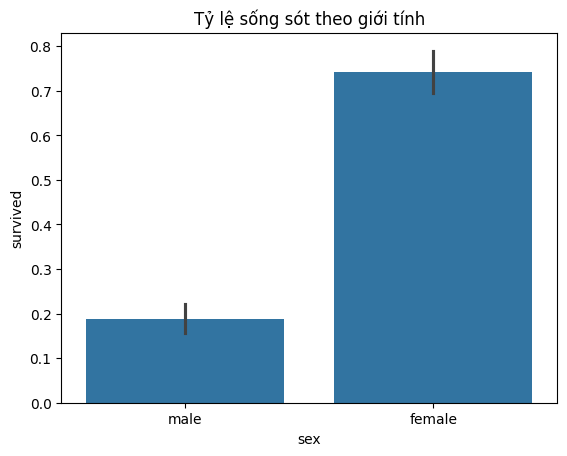

In [49]:
sns.barplot(data=titanic, x="sex", y="survived")
plt.title("Tỷ lệ sống sót theo giới tính")
plt.show()

Biểu đồ cho thấy nữ giới có tỷ lệ sống sót vượt trội.

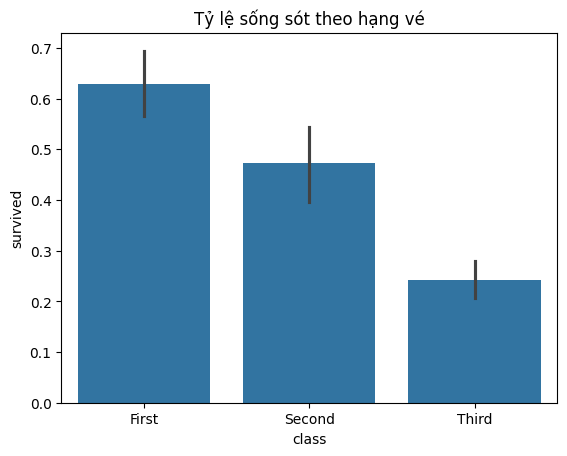

In [50]:
sns.barplot(data=titanic, x="class", y="survived")
plt.title("Tỷ lệ sống sót theo hạng vé")
plt.show()

Hành khách hạng nhất có khả năng sống sót cao hơn các hạng khác.

# SECTION D — New Questions

1. Người đi một mình có sống sót ít hơn không?

2. Nhóm tuổi nào trả giá vé cao nhất?

3. Cảng lên tàu có ảnh hưởng đến tỷ lệ sống sót không?

4. Trẻ em thường đi ở hạng vé nào?

5. Kích thước gia đình có ảnh hưởng đến khả năng sống sót không?

In [51]:
titanic.groupby("alone")["survived"].mean()

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64

Người đi cùng gia đình hoặc bạn bè có tỷ lệ sống sót cao hơn người đi một mình.

In [52]:
titanic.groupby("embark_town")["survived"].mean()

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64

Tỷ lệ sống sót khác nhau theo từng cảng lên tàu.

# Conclusion

Qua quá trình phân tích dataset Titanic:

- Phụ nữ có tỷ lệ sống sót cao hơn nam giới.
- Hành khách hạng nhất có khả năng sống sót cao hơn.
- Giá vé có liên quan đến khả năng sống sót.
- Dataset có một số giá trị thiếu, đặc biệt ở cột age và deck.

Bài tập giúp luyện tập kỹ năng:
- xử lý dữ liệu bằng Pandas
- trực quan hóa dữ liệu bằng Seaborn
- phân tích và đặt câu hỏi từ dữ liệu thực tế